In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2                                                                                                                                
import warnings
import os
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization
from keras.utils import image_dataset_from_directory, to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.vis_utils import plot_model
from tensorflow import convert_to_tensor
from glob import glob

warnings.filterwarnings('ignore')

train_path = 'C://Users//QF626RJ//OneDrive - EY//Documents//Projects//waste-classifier//DATASET//DATASET//TRAIN'
test_path = 'C://Users//QF626RJ//OneDrive - EY//Documents//Projects//waste-classifier//DATASET//DATASET//TEST'

# visualize dataset
x_data = []
y_data = []

def create_dataset(path):
    for category in glob(path + '/*'):
        for file in glob(category + '/*'):
            img_array = cv2.imread(file)
            img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
            x_data.append(img_array)
            y_data.append(category.split('\\')[-1])

    data = pd.DataFrame({'image': x_data, 'label': y_data})
    return data

In [2]:
train = create_dataset(train_path)
train.head(5)

,image,label
0,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",O
1,"[[[241, 242, 247], [241, 242, 247], [241, 242,...",O
2,"[[[224, 224, 224], [229, 229, 229], [236, 236,...",O
3,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",O
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",O


In [3]:
test = create_dataset(test_path)
test.head(-5)

,image,label
0,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",O
1,"[[[241, 242, 247], [241, 242, 247], [241, 242,...",O
2,"[[[224, 224, 224], [229, 229, 229], [236, 236,...",O
3,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",O
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",O
...,...,...
25067,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",R
25068,"[[[194, 193, 199], [195, 194, 200], [196, 195,...",R
25069,"[[[254, 254, 254], [254, 254, 254], [254, 254,...",R
25070,"[[[242, 241, 237], [242, 241, 237], [242, 241,...",R


In [4]:
train.shape

(22564, 2)

In [5]:
from collections import Counter
Counter(y_data)

Counter({'O': 13966, 'R': 11111})

([<matplotlib.patches.Wedge at 0x244666a0910>,
 [Text(-1.0824963456092194, -0.1954524539183007, 'Organic'),
  Text(1.0824963273096353, 0.19545255526892205, 'Recyclable')],
 [Text(-0.5904525521504832, -0.10661042940998221, '55.69%'),
  Text(0.590452542168892, 0.10661048469213928, '44.31%')])

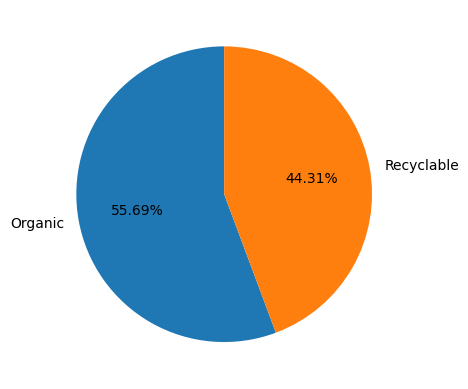

In [6]:
plt.pie(train.label.value_counts(), labels = ['Organic', 'Recyclable'], autopct='%0.2f%%', startangle=90)

In [7]:
train.label.value_counts()

O    12565
R     9999
Name: label, dtype: int64

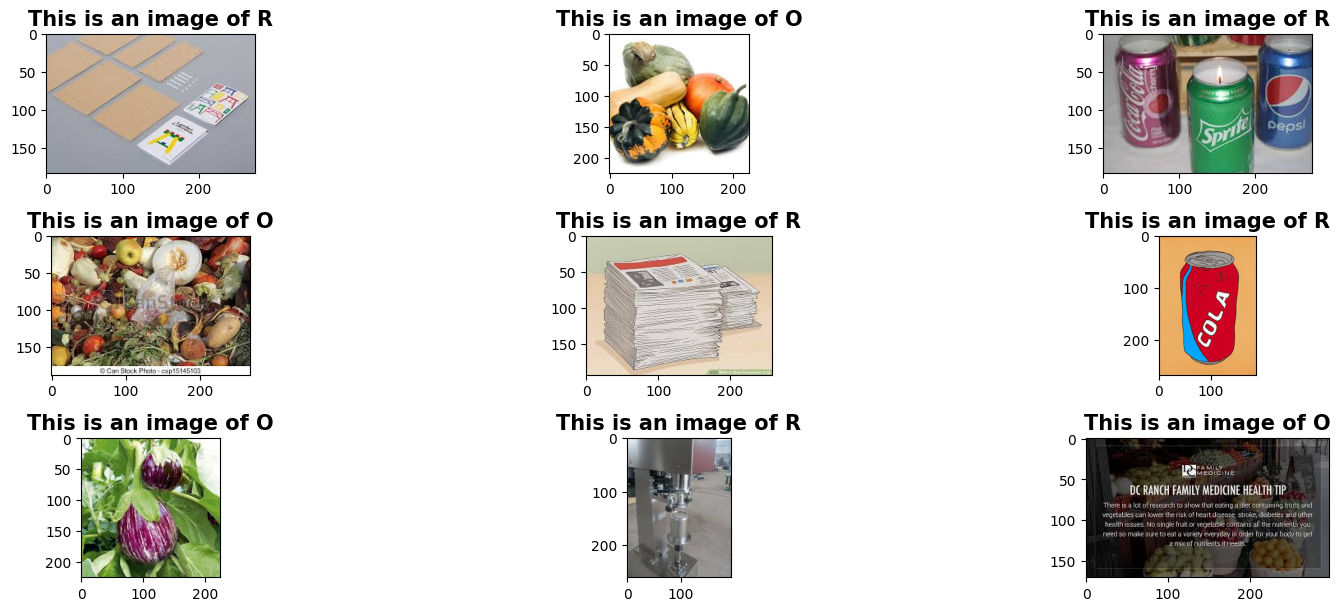

In [8]:
plt.figure(figsize=(16,8))
for i in range(9):
    plt.subplot(4,3, (i%12)+1)
    index = np.random.randint(15000)
    plt.title(f'This is an image of {train.label[index]}', fontdict={'size': 15, 'weight': 'bold'})
    plt.imshow(train.image[index])
    plt.tight_layout()

In [9]:
# Train CNN
input_shape = (224,224,3)
model = Sequential()

# first convolutional layer
model.add(Conv2D(32, (3,3), input_shape = input_shape, activation = 'relu'))
model.add(MaxPooling2D())

# second convolutional layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())

# flatten
model.add(Flatten())
model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output layer
num_classes = len(glob(train_path + '/*'))
model.add(Dense(num_classes))
model.add(Activation('sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
batch_size = 256

In [10]:
plot_model(model)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 186624)            0         
                                                                 
 dense (Dense)               (None, 256)               4

In [12]:
# prepare dataset for training
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_generator =train_gen.flow_from_directory(train_path,
                                                batch_size=batch_size,
                                                target_size=(224,224),
                                                color_mode='rgb',
                                                class_mode='categorical')

test_generator =test_gen.flow_from_directory(test_path,
                                                batch_size=batch_size,
                                                target_size=(224,224),
                                                color_mode='rgb',
                                                class_mode='categorical')

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [13]:
# train the model
img_classifier = model.fit(train_generator, epochs=30, validation_data=test_generator)

Epoch 1/30
89/89 [==============================] - 660s 7s/step - loss: 1.1528 - accuracy: 0.7742 - val_loss: 0.3062 - val_accuracy: 0.8762
Epoch 2/30
89/89 [==============================] - 685s 8s/step - loss: 0.4038 - accuracy: 0.8283 - val_loss: 0.3086 - val_accuracy: 0.8731
Epoch 3/30
89/89 [==============================] - 2552s 29s/step - loss: 0.3620 - accuracy: 0.8468 - val_loss: 0.3510 - val_accuracy: 0.8552
Epoch 4/30
89/89 [==============================] - 639s 7s/step - loss: 0.3279 - accuracy: 0.8613 - val_loss: 0.3118 - val_accuracy: 0.8842
Epoch 5/30
89/89 [==============================] - 74787s 850s/step - loss: 0.2976 - accuracy: 0.8759 - val_loss: 0.3524 - val_accuracy: 0.8484
Epoch 6/30
89/89 [==============================] - 704s 8s/step - loss: 0.2477 - accuracy: 0.9011 - val_loss: 0.3071 - val_accuracy: 0.8846
Epoch 7/30
89/89 [==============================] - 3923s 44s/step - loss: 0.2185 - accuracy: 0.9133 - val_loss: 0.3469 - val_accuracy: 0.8798
Epoch

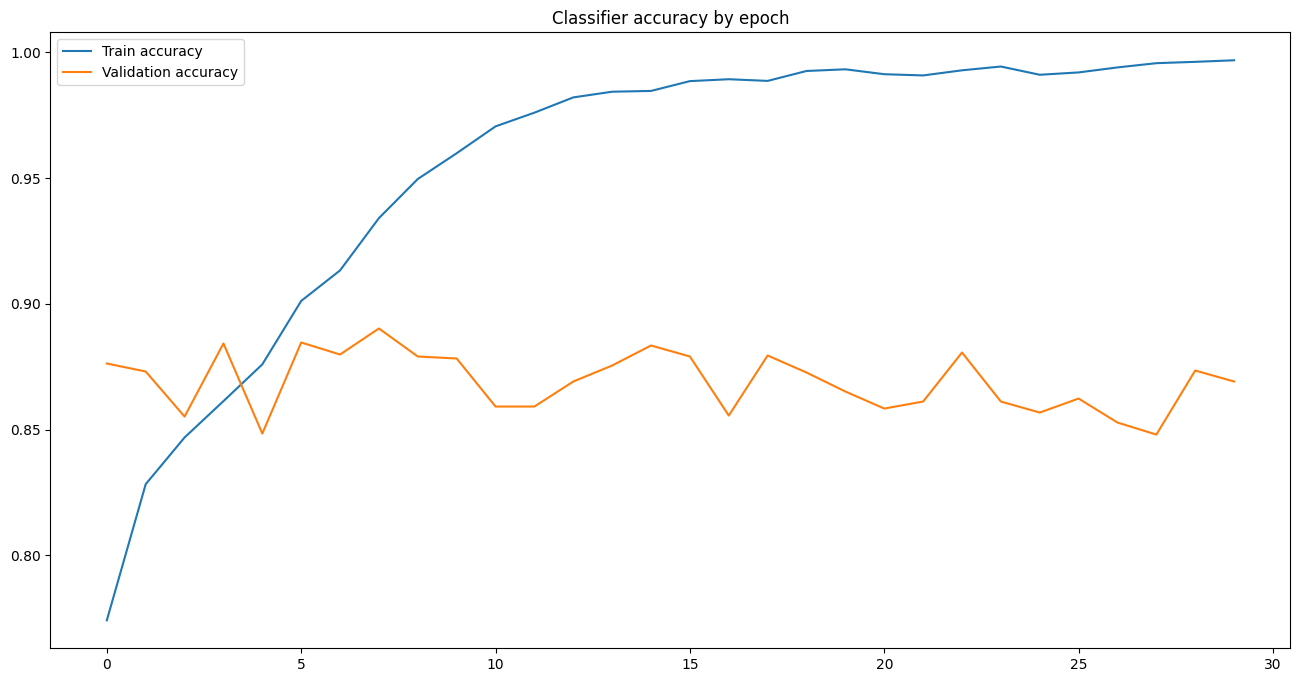

In [19]:
# evaluate model accuracy
plt.figure(figsize=(16,8))
plt.plot(img_classifier.history['accuracy'], label='Train accuracy')
plt.plot(img_classifier.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.title('Classifier accuracy by epoch')
plt.show()

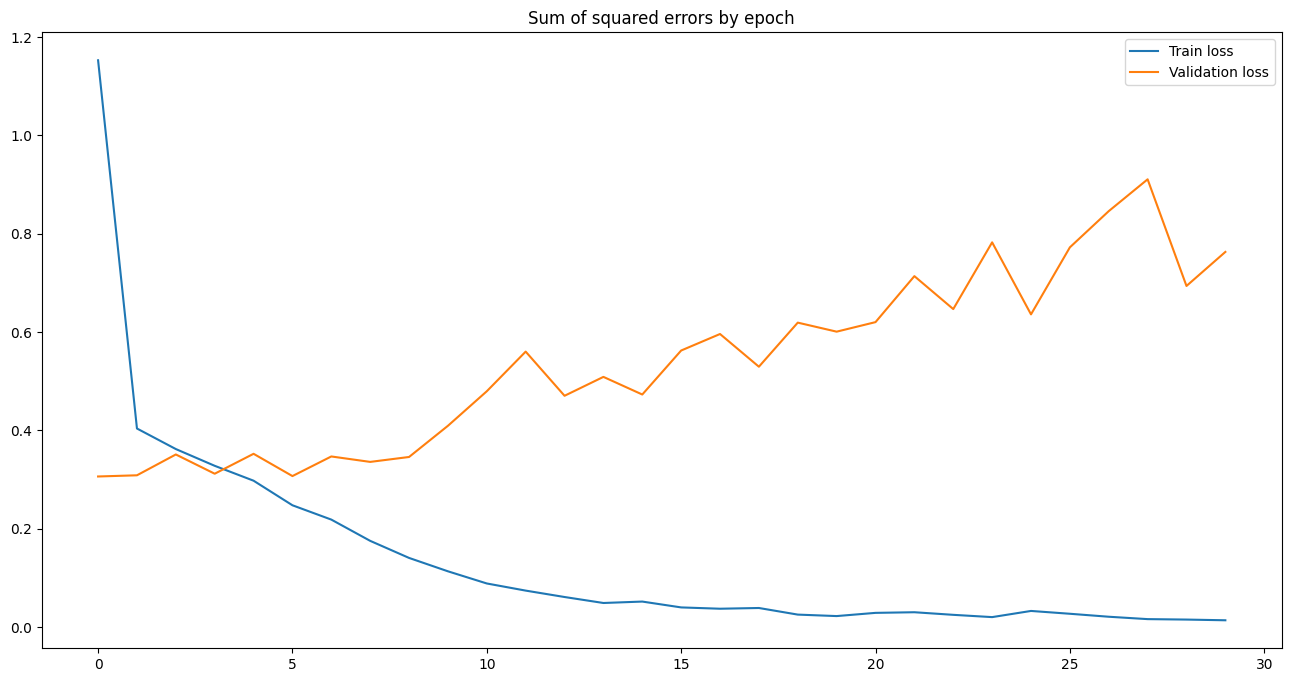

In [20]:
# evaluate model loss
plt.figure(figsize=(16,8))
plt.plot(img_classifier.history['loss'], label='Train loss')
plt.plot(img_classifier.history['val_loss'], label='Validation loss')
plt.legend()
plt.title('Sum of squared errors by epoch')
plt.show()

# Classifier prediction

1/1 [==============================] - 0s 49ms/step
[[0. 1.]]
Result --->  1
This item is organic material. Dispose of it in your brown bin to recycle it.


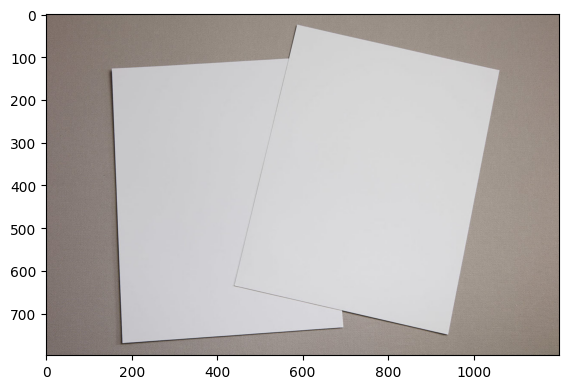

In [47]:
# predictions from the classifier
def predict_waste_material_from_img(img):
    # plot image
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    img = cv2.resize(img, (224, 224))
    img = np.reshape(img, [-1, 224, 224,3])
    result = np.argmax(model.predict(img))
    prediction = ''

    print(model.predict(img))
    print("Result ---> ", result)
    if result == 0:
        prediction = 'R'
    elif result == 1:
        prediction = 'O'
    
    return prediction

test_img = cv2.imread(test_path + '/R/R_112233.jpg')
img_predict = predict_waste_material_from_img(test_img)
if(img_predict == 'O'):
    print('This item is organic material. Dispose of it in your brown bin to recycle it.')
elif(img_predict == 'R'):
    print('This item is non-organic recyclable material. Dispose of it in your blue bin to recycle it.')